Importlar ve device seçimi

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


MNIST datasetini yükleme

In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.34MB/s]


VAE modelini tanımlama

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 400),
            nn.ReLU()
        )

        # Latent distribution parameters
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat

    def forward(self, x):
        x = x.view(x.size(0), -1)

        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        x_hat = x_hat.view(x.size(0), 1, 28, 28)

        return x_hat, mu, logvar

input → encoder → mu, logvar → z örnekleme → decoder → output

VAE loss function

In [5]:
def vae_loss(reconstructed, original, mu, logvar):
    # Reconstruction loss
    BCE = nn.functional.binary_cross_entropy(
        reconstructed,
        original,
        reduction="sum"
    )

    # KL divergence loss
    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD, BCE, KLD

Total Loss = Reconstruction Loss + KL Divergence

Reconstruction loss, üretilen görüntünün input’a ne kadar benzediğini ölçer.

KL divergence, latent space’in düzenli bir normal dağılıma benzemesini sağlar. Bu sayede daha sonra random z seçip yeni görüntü üretebiliriz.

Model, optimizer ve eğitim ayarları

In [6]:
latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

train_losses = []
reconstruction_losses = []
kl_losses = []

Training loop

In [7]:
for epoch in range(num_epochs):
    model.train()

    total_loss = 0
    total_bce = 0
    total_kld = 0

    for images, _ in train_loader:
        images = images.to(device)

        reconstructed, mu, logvar = model(images)

        loss, bce, kld = vae_loss(reconstructed, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    avg_loss = total_loss / len(train_dataset)
    avg_bce = total_bce / len(train_dataset)
    avg_kld = total_kld / len(train_dataset)

    train_losses.append(avg_loss)
    reconstruction_losses.append(avg_bce)
    kl_losses.append(avg_kld)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Total Loss: {avg_loss:.4f} | "
        f"Reconstruction Loss: {avg_bce:.4f} | "
        f"KL Loss: {avg_kld:.4f}"
    )

Epoch [1/10] Total Loss: 165.2805 | Reconstruction Loss: 149.8678 | KL Loss: 15.4127
Epoch [2/10] Total Loss: 121.4695 | Reconstruction Loss: 98.9135 | KL Loss: 22.5560
Epoch [3/10] Total Loss: 114.6181 | Reconstruction Loss: 90.4827 | KL Loss: 24.1355
Epoch [4/10] Total Loss: 111.6593 | Reconstruction Loss: 87.0161 | KL Loss: 24.6432
Epoch [5/10] Total Loss: 109.9227 | Reconstruction Loss: 85.0398 | KL Loss: 24.8830
Epoch [6/10] Total Loss: 108.7440 | Reconstruction Loss: 83.7370 | KL Loss: 25.0071
Epoch [7/10] Total Loss: 107.8917 | Reconstruction Loss: 82.7949 | KL Loss: 25.0968
Epoch [8/10] Total Loss: 107.2706 | Reconstruction Loss: 82.0778 | KL Loss: 25.1929
Epoch [9/10] Total Loss: 106.7211 | Reconstruction Loss: 81.4403 | KL Loss: 25.2808
Epoch [10/10] Total Loss: 106.3436 | Reconstruction Loss: 81.0085 | KL Loss: 25.3351


Training loss grafiği

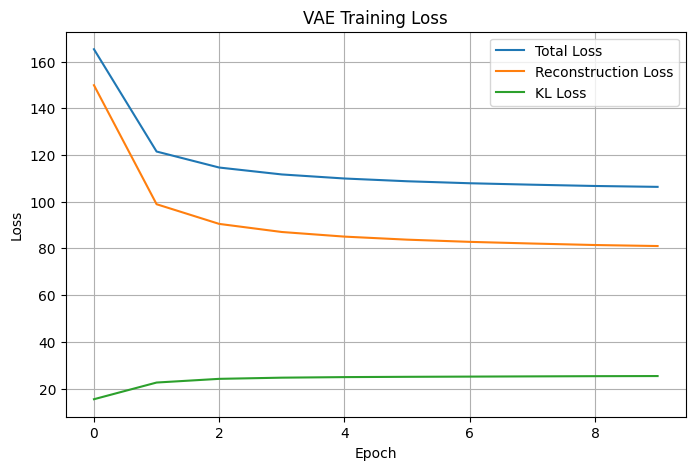

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid(True)
plt.show()

Dataset’ten gerçek MNIST görüntülerini gösterme

In [9]:
def show_images(images, title):
    images = images.cpu()

    grid = make_grid(images, nrow=8, padding=2)
    np_grid = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_grid, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

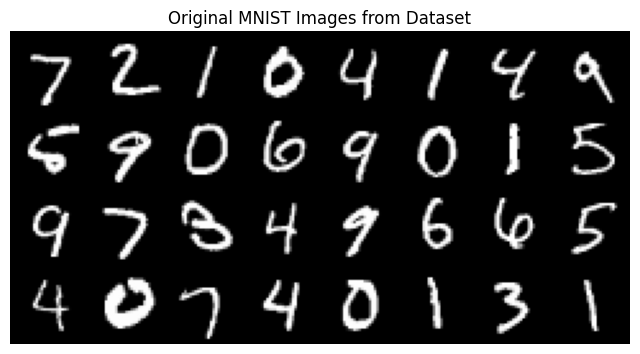

In [10]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

show_images(images[:32], "Original MNIST Images from Dataset")

Original ve reconstructed görüntüleri karşılaştırma

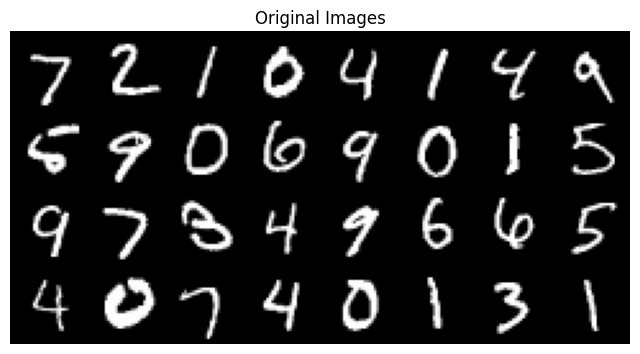

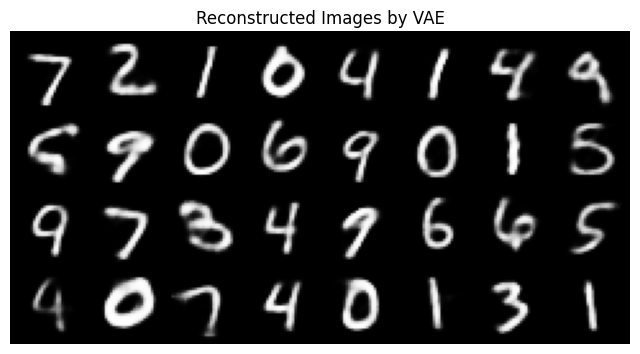

In [11]:
model.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images.to(device)

    reconstructed, mu, logvar = model(images)

show_images(images[:32], "Original Images")
show_images(reconstructed[:32], "Reconstructed Images by VAE")

Yeni generated MNIST görüntüleri üretme

random z → decoder → generated image

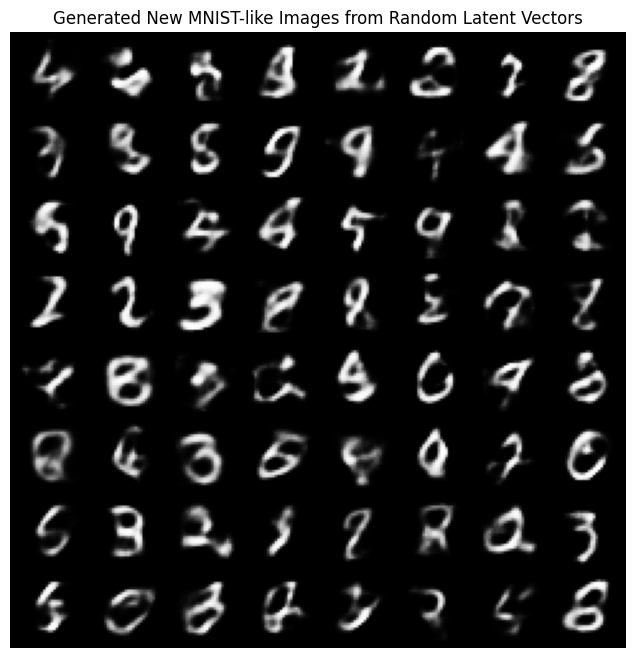

In [12]:
model.eval()

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    generated = model.decode(z)
    generated = generated.view(64, 1, 28, 28)

show_images(generated, "Generated New MNIST-like Images from Random Latent Vectors")